### Avg heatmap for a network using 20 transition node communities data

Import packages

In [8]:
import sys
import pickle
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

In [3]:
with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

In [18]:
df_itr=pd.read_pickle('../../data/raw/FN/itr_data_fn.bz2')
df_nc=pd.read_pickle('../../data/raw/check_20/nc_fn_20.bz2')
df_lo=pd.read_pickle('../../data/raw/FN/l200.bz2')
df_toe = pd.read_pickle('../../data/raw/check_20/toe_fn_20.bz2')

In [103]:
df_nc=pd.read_pickle('../../data/raw/check_4/nc_pir_4.bz2')

In [104]:
array_list = []
for p in range(1,5):
    
    

    if (df_nc.loc[p])[23].value_counts().size==1:
        main_cluster_index=0
    else:
        
        main_cluster_index = (df_nc.loc[p])[23].value_counts().index[1]
    #Read node community data for a transition
    matrix=df_nc.loc[p].values
    #Desired order i.e the sequence in which communities enter final cluster  in FN
    
    
    #the order in which community enters main cluster (may need to check)
    desired_keys = [3,6,4,2,0,7,1,5]
    #Arranged _x dictionary data in desired order
    _x_rearrange = {key: _x[key] for key in desired_keys}
    desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
    rearranged_matrix = matrix[:, desired_order]
    #counting nodes in each community
    len_comm=[len(v) for v in _x_rearrange.values()]
    #Calculating time spent and sorting in descending order community wise
    
    time_spent=0
    ts=[]
    #c for comm. [0 to 7]
    com_count=0
    c=0
    last=len_comm[0]
    dict_sort={}
    
    for l in range(0,8):
        #l for iterating communities
        keys=[]
        values=[]
        for i in range(c,last):
            #i for iterating node
            
            for j in range(0,5000):
                #j for iterating timestep
                        
                if rearranged_matrix[j][i] == main_cluster_index:
                    time_spent+=1
                            
                else:
                    pass
                
            ts.append(time_spent)
            time_spent=0
    
        keys=list(range(c,last))
        values=ts[c:last]
        dict_0=dict(zip(keys,values))
        sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
        dict_sort = dict_sort | sorted_dict_dum
        c=last
        com_count+=1
        if com_count<8:
            last=last+len_comm[com_count]
        else:
            break
    
    #rearranging matrix in the new order
    new_order=list(dict_sort.keys())
    final_matrix = rearranged_matrix[:, new_order]
    
    #np.place(final_matrix,final_matrix==0,np.nan)
    #np.place(final_matrix,final_matrix!=main_cluster_index and final_matrix!=0,-1)
    np.place(final_matrix,final_matrix==main_cluster_index,1)
    np.place(final_matrix, (final_matrix != main_cluster_index) & (final_matrix != 0), -1)
    np.place(final_matrix,final_matrix==0,np.nan)

    array_list.append(final_matrix)

stacked_matrices = np.stack(array_list, axis=0)
average_matrix = np.mean(stacked_matrices, axis=0)


    




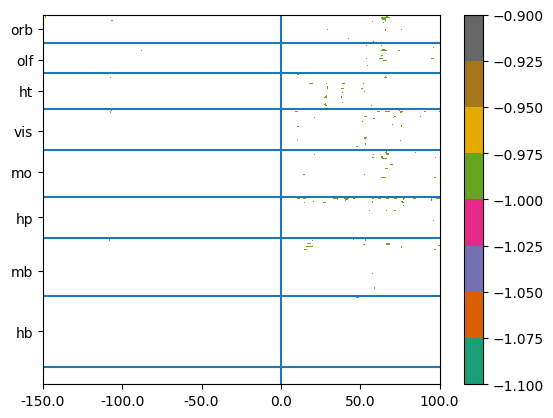

In [105]:
fig,axs = plt.subplots()
cax=axs.imshow(average_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs.axhline(_i)
axs.axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs.set_xticks(xc_tick) 
axs.set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs.set_yticks(label_in)
axs.set_yticklabels(label)
fig.colorbar(cax,ax=axs)

In [59]:
fn_avg_matrix = average_matrix

In [68]:
bla_avg_matrix = average_matrix #17 iterations

In [71]:
peri_avg_matrix = average_matrix

In [75]:
enti_avg_matrix = average_matrix

In [79]:
pir_avg_matrix = average_matrix

In [83]:
re_avg_matrix=average_matrix #re matrix 19

In [87]:
orb_avg_matrix=average_matrix

In [88]:
keys=['fn','bla','peri','enti','pir','re','orb']
values=[fn_avg_matrix,bla_avg_matrix,peri_avg_matrix,enti_avg_matrix,pir_avg_matrix,re_avg_matrix,orb_avg_matrix]

In [90]:
import pickle
with open('avg_4.pkl', 'wb') as f: 
    pickle.dump(avg_mat_heat,f)

In [96]:
len(values)

6

In [89]:
avg_mat_heat=dict(zip(keys,values))

Plot these on Y axis

NameError: name 'im' is not defined

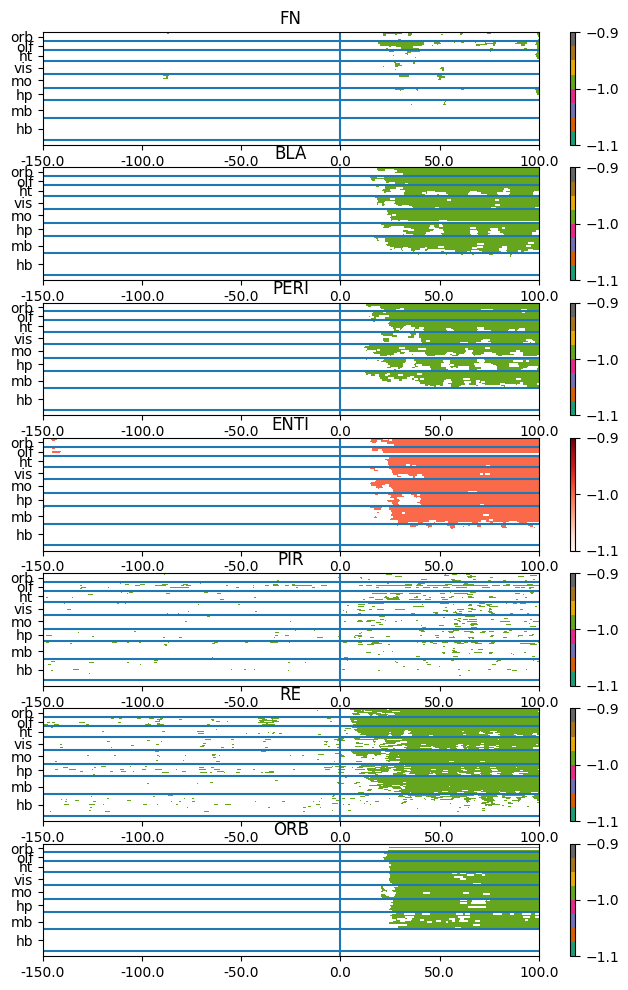

In [106]:
fig,axs = plt.subplots(7,1,figsize=(8, 12))

cax=axs[0].imshow(fn_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[0].axhline(_i)
axs[0].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[0].set_title('FN')
axs[0].set_xticks(xc_tick) 
axs[0].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[0].set_yticks(label_in)
axs[0].set_yticklabels(label)
fig.colorbar(cax,ax=axs[0])

#bla
cax=axs[1].imshow(bla_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[1].axhline(_i)
axs[1].axvline(3000)
axs[1].set_title('BLA')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[1].set_xticks(xc_tick) 
axs[1].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)
fig.colorbar(cax,ax=axs[1])

#peri
cax=axs[2].imshow(peri_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[2].axhline(_i)
axs[2].axvline(3000)
axs[2].set_title('PERI')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[2].set_xticks(xc_tick) 
axs[2].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[2].set_yticks(label_in)
axs[2].set_yticklabels(label)
fig.colorbar(cax,ax=axs[2])

#enti
cax=axs[3].imshow(enti_avg_matrix.T,cmap='Reds',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[3].axhline(_i)
axs[3].axvline(3000)
axs[3].set_title('ENTI')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[3].set_xticks(xc_tick) 
axs[3].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[3].set_yticks(label_in)
axs[3].set_yticklabels(label)
fig.colorbar(cax,ax=axs[3])


#pir
cax=axs[4].imshow(pir_avg_matrix.T,cmap='Dark2',interpolation='nearest',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[4].axhline(_i)
axs[4].axvline(3000)
axs[4].set_title('PIR')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[4].set_xticks(xc_tick) 
axs[4].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[4].set_yticks(label_in)
axs[4].set_yticklabels(label)
fig.colorbar(cax,ax=axs[4])


#re
cax=axs[5].imshow(re_avg_matrix.T,cmap='Dark2',interpolation='nearest',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[5].axhline(_i)
axs[5].axvline(3000)
axs[5].set_title('RE')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[5].set_xticks(xc_tick) 
axs[5].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[5].set_yticks(label_in)
axs[5].set_yticklabels(label)
fig.colorbar(cax,ax=axs[5])


#orb
cax=axs[6].imshow(orb_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[6].axhline(_i)
axs[6].axvline(3000)
axs[6].set_title('ORB')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[6].set_xticks(xc_tick) 
axs[6].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[6].set_yticks(label_in)
axs[6].set_yticklabels(label)
fig.colorbar(cax,ax=axs[6])

cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Value')

plt.savefig('all_avg_hmap.png')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Generate example data (20 matrices with values -1, 0, 1)
matrices = [np.random.choice([-1, 0, 1], size=(5, 5)) for _ in range(20)]

# Calculate the average matrix
average_matrix = np.mean(matrices, axis=0)

# Determine global min and max
global_min = -1
global_max = 1

# Normalize the colormap to the global min and max
norm = Normalize(vmin=global_min, vmax=global_max)
cmap = plt.get_cmap('coolwarm')

# Create subplots
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

# Plot each matrix
for ax, matrix in zip(axes, matrices):
    im = ax.imshow(matrix, cmap=cmap, norm=norm, interpolation='nearest')
    ax.axis('off')

# Add a single colorbar for all plots
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Value')

plt.tight_layout()
plt.show()


#### Centrality


In [3]:
import pickle
with open('centrality.pkl', 'rb') as f: 
    cent=pickle.load(f)

In [4]:
print(cent)

{0: 0.09411764705882353, 1: 0.3364705882352941, 2: 0.3035294117647059, 3: 0.07529411764705882, 4: 0.1764705882352941, 5: 0.18352941176470586, 6: 0.08470588235294117, 7: 0.12, 8: 0.1388235294117647, 9: 0.1341176470588235, 10: 0.1364705882352941, 11: 0.06117647058823529, 12: 0.11294117647058823, 13: 0.051764705882352935, 14: 0.1411764705882353, 15: 0.0776470588235294, 16: 0.1341176470588235, 17: 0.10823529411764705, 18: 0.11058823529411764, 19: 0.03764705882352941, 20: 0.0588235294117647, 21: 0.19999999999999998, 22: 0.10823529411764705, 23: 0.09411764705882353, 24: 0.2188235294117647, 25: 0.19058823529411764, 26: 0.08235294117647059, 27: 0.1176470588235294, 28: 0.1176470588235294, 29: 0.13176470588235292, 30: 0.10352941176470587, 31: 0.07294117647058823, 32: 0.051764705882352935, 33: 0.12235294117647058, 34: 0.1788235294117647, 35: 0.13176470588235292, 36: 0.27999999999999997, 37: 0.09647058823529411, 38: 0.018823529411764704, 39: 0.047058823529411764, 40: 0.07058823529411765, 41: 0.12,

In [5]:
central_sort = {k: v for k, v in sorted(cent.items(), key=lambda item: item[1],reverse=True)}

In [6]:
central_sort

{1: 0.3364705882352941,
 214: 0.3364705882352941,
 2: 0.3035294117647059,
 215: 0.3035294117647059,
 137: 0.30117647058823527,
 350: 0.30117647058823527,
 36: 0.27999999999999997,
 249: 0.27999999999999997,
 53: 0.2564705882352941,
 266: 0.2564705882352941,
 140: 0.25176470588235295,
 353: 0.25176470588235295,
 150: 0.24470588235294116,
 363: 0.24470588235294116,
 149: 0.24235294117647058,
 362: 0.24235294117647058,
 151: 0.22823529411764704,
 364: 0.22823529411764704,
 24: 0.2188235294117647,
 237: 0.2188235294117647,
 113: 0.21411764705882352,
 169: 0.21411764705882352,
 326: 0.21411764705882352,
 382: 0.21411764705882352,
 141: 0.2117647058823529,
 354: 0.2117647058823529,
 193: 0.20235294117647057,
 406: 0.20235294117647057,
 21: 0.19999999999999998,
 84: 0.19999999999999998,
 164: 0.19999999999999998,
 234: 0.19999999999999998,
 297: 0.19999999999999998,
 377: 0.19999999999999998,
 58: 0.1976470588235294,
 83: 0.1976470588235294,
 167: 0.1976470588235294,
 271: 0.1976470588235294,

d 36
P
d 249
p
d 53
E
d 266
e
d 113
R
d 326
r
d 64
B
d 277
b
d 43
Pi
d 256
pi
d 23
O
d 236
o


(0.1, 0.3)

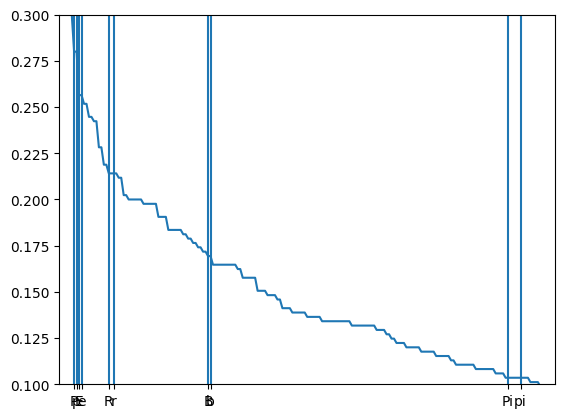

In [76]:
fig,ax= plt.subplots()
labels=['P','p','E','e','O','o','R','r','B','b','Pi','pi']
noi=[36,249,53,266,23,236,113,326,64,277,43,256,23,236]
name_map=dict(zip(noi,labels))
ax.plot(central_sort.values())
#make dictionary which map 0 to 425 to sort order
des_order=list(central_sort.keys())
order=list(range(0,426))
map_dict=dict(zip(des_order,order))
rev_map_dict = dict(zip(order,des_order))
xtick=[]
xlabels=[]
for i in des_order:
    
    if i in noi:
        #print(i)
        ax.vlines(map_dict[i],0,0.3)
        
        xtick.append(map_dict[i])


ax.set_xticks(xtick)
for d in xtick:
    print("d",rev_map_dict[d])
    k=rev_map_dict[d]
    print(name_map[k])
    xlabels.append(name_map[k])
ax.set_xticklabels(xlabels)
ax.set_xlim(0,200)
ax.set_ylim(0.10,0.30)
    

In [49]:
xtick

[6, 7, 8, 9, 20, 22, 60, 61, 181, 186, 213, 219]